# Tugas 05 : **keyword extraction**

NAMA : Mohammad Hasan Basri

NIM  : 210411100169

MATA KULIAH : Pencarian dan Penambangan Web - A

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import re
import nltk
!pip install Sastrawi
nltk.download('punkt')
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from nltk.tokenize import sent_tokenize

import networkx as nx
import matplotlib.pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 4.1 MB/s eta 0:00:00


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


In [3]:
import pandas as pd

df = pd.read_csv("/content/drive/My Drive/PPWA/report/Tugas_PPWA/Hasil_Preprocessing_Hasan.csv")
df.head(100)

,judul,tanggal,isi,kategori,cleansing,case_folding,tokenize,stopword_removal
0,Iran Serukan Negara Muslim Bersatu Hentikan Ke...,"Kamis, 17 Okt 2024 10:01 WIB",Jakarta - Presiden Iran Masoud Pezeshkian mene...,Keislaman,Jakarta Presiden Iran Masoud Pezeshkian menek...,jakarta presiden iran masoud pezeshkian menek...,"['jakarta', 'presiden', 'iran', 'masoud', 'pez...",jakarta presiden iran masoud pezeshkian meneka...
1,"Bacaan Al-Qur'an Surah Asy-Syu'ara: Arab, Lati...","Kamis, 17 Okt 2024 09:30 WIB",NaN,Keislaman,NaN,NaN,['nan'],NaN
2,"Rukun Iman Ke-2, Setiap Muslim Wajib Mengimani...","Kamis, 17 Okt 2024 08:45 WIB",Jakarta - Malaikat adalah makhluk ciptaan Alla...,Keislaman,Jakarta Malaikat adalah makhluk ciptaan Allah...,jakarta malaikat adalah makhluk ciptaan allah...,"['jakarta', 'malaikat', 'adalah', 'makhluk', '...",jakarta malaikat makhluk ciptaan allah swt mus...
3,Kalender Ramadhan 2025 Muhammadiyah dan Predik...,"Kamis, 17 Okt 2024 08:00 WIB",Jakarta - Kalender Ramadhan 2025 versi Muhamma...,Keislaman,Jakarta Kalender Ramadhan versi Muhammadiyah...,jakarta kalender ramadhan versi muhammadiyah...,"['jakarta', 'kalender', 'ramadhan', 'versi', '...",jakarta kalender ramadhan versi muhammadiyah t...
4,20 Gambaran Kehidupan di Neraka Menurut Al-Qur...,"Kamis, 17 Okt 2024 07:15 WIB",Jakarta - Gambaran kehidupan di neraka selalu ...,Keislaman,Jakarta Gambaran kehidupan di neraka selalu m...,jakarta gambaran kehidupan di neraka selalu m...,"['jakarta', 'gambaran', 'kehidupan', 'di', 'ne...",jakarta gambaran kehidupan neraka pengingat ke...
...,...,...,...,...,...,...,...,...
95,"Praha Incar Turis-Turis Kaya, 'Wisata Pub Jala...","Rabu, 16 Okt 2024 06:13 WIB",Praha - Praha ingin mengganti imej dari kota s...,Pariwisata,Praha Praha ingin mengganti imej dari kota se...,praha praha ingin mengganti imej dari kota se...,"['praha', 'praha', 'ingin', 'mengganti', 'imej...",praha praha mengganti imej kota tujuan wisata ...
96,"Usai Festival Vegetarian, Phuket Pusing dengan...","Rabu, 16 Okt 2024 05:39 WIB",Phuket - Festival Vegetarian menjadi salah sat...,Pariwisata,Phuket Festival Vegetarian menjadi salah satu...,phuket festival vegetarian menjadi salah satu...,"['phuket', 'festival', 'vegetarian', 'menjadi'...",phuket festival vegetarian salah daya tarik pa...
97,Ngeri! Turis Inggris Tewas Saat Memanjat Jemba...,"Rabu, 16 Okt 2024 05:01 WIB",Jakarta - Seorang turis yang juga kreator kont...,Pariwisata,Jakarta Seorang turis yang juga kreator konte...,jakarta seorang turis yang juga kreator konte...,"['jakarta', 'seorang', 'turis', 'yang', 'juga'...",jakarta turis kreator konten inggris berusia t...
98,Info Loker: Lion Group Buka Lowongan Mekanik Nih!,"Selasa, 15 Okt 2024 23:04 WIB",Jakarta - Traveler yang ingin bekerja di dunia...,Pariwisata,Jakarta Traveler yang ingin bekerja di dunia ...,jakarta traveler yang ingin bekerja di dunia ...,"['jakarta', 'traveler', 'yang', 'ingin', 'beke...",jakarta traveler dunia aviasi baiknya simak in...


In [4]:
# Mengambil satu sample berita
sample_berita = df['stopword_removal'].iloc[4]

sample_berita_list = [sample_berita]
print(sample_berita_list)


['jakarta gambaran kehidupan neraka pengingat keras ajaran islam menggambarkan balasan menyimpang jalan kebenaran alquran hadits menggambarkan kehidupan neraka simak gambaran rinci membuka mata menyadarkan kumpulan gambaran kehidupan neraka alquran hadits kehidupan neraka digambarkan rinci siksa api membakar penderitaan menimpa penghuninya kumpulan gambaran bayangan dahsyatnya siksa mengabaikan perintah allah swt gambaran kehidupan neraka tercantum alquran hadits luas besarnya neraka berdasarkan informasi buku jauhi neraka khalid abu syady luas besarnya neraka digambarkan hadits neraka jahanam memiliki ribuan tali kekang diseret malaikat rasulullah saw bersabda neraka jahanam tujuh puluh ribu tali kekang tali kekang tujuh puluh ribu malaikat menyeretnya hr muslim tirmidzi neraka menampung matahari digambarkan rasulullah saw hadits diriwayatkan ibnu masud ra beliau bersabda matahari sapi diikat dilemparkan neraka kiamat hr muslim tirmidzi neraka terisi penuh allah swt menempatkan kakiny

In [5]:
import networkx as nx
from sklearn.feature_extraction.text import TfidfVectorizer

# Inisialisasi TfidfVectorizer tanpa batasan jumlah fitur
vectorizer = TfidfVectorizer()

# Fit dan transform teks ke dalam TF-IDF
tfidf_matrix = vectorizer.fit_transform(sample_berita_list)

# Konversi TF-IDF matrix ke DataFrame
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=vectorizer.get_feature_names_out())

tfidf_df.head()

,abadi,abu,adam,air,ajaran,akal,alami,alaraf,alas,alasyqar,...,tujuh,ujung,ukuran,umar,umat,unta,uraian,uraiannya,wajah,zalim
0,0.010477,0.010477,0.010477,0.083812,0.010477,0.010477,0.010477,0.010477,0.020953,0.010477,...,0.104765,0.010477,0.010477,0.010477,0.010477,0.010477,0.010477,0.010477,0.020953,0.010477


In [6]:
# Ubah nilai TF-IDF di bawah 0.5 menjadi 0, dan di atas atau sama dengan 0.5 menjadi 1
df_tfidf_1berita = tfidf_df.apply(lambda col: col.map(lambda x: 1 if x >= 0.03 else 0))

# Menampilkan DataFrame dengan nilai biner
df_tfidf_1berita

,abadi,abu,adam,air,ajaran,akal,alami,alaraf,alas,alasyqar,...,tujuh,ujung,ukuran,umar,umat,unta,uraian,uraiannya,wajah,zalim
0,0,0,0,1,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0


In [7]:
# Membuat graf berdasarkan co-occurrence fitur
G = nx.Graph()

# Menambahkan node ke graf
for feature in df_tfidf_1berita.columns:
    G.add_node(feature)

# Menambahkan edge berdasarkan co-occurrence
for i in range(len(df_tfidf_1berita)):
    features = df_tfidf_1berita.iloc[i]
    active_features = features[features == 1].index.tolist()

    for j in range(len(active_features)):
        for k in range(j + 1, len(active_features)):
            G.add_edge(active_features[j], active_features[k])

# Hitung degree centrality
degree_centrality = nx.degree_centrality(G)

# Konversi hasil degree centrality ke DataFrame
df_degree_centrality = pd.DataFrame(degree_centrality.items(), columns=['Node', 'Degree Centrality'])

# Mengurutkan DataFrame dari yang terbesar sampai terkecil
df_degree_centrality_sorted = df_degree_centrality.sort_values(by='Degree Centrality', ascending=False)

# Tampilkan hasil degree centrality yang sudah diurutkan
print(df_degree_centrality_sorted)

           Node  Degree Centrality
336     shirath           0.155039
313  rasulullah           0.155039
85   dahsyatnya           0.155039
150    jembatan           0.155039
321         saw           0.155039
..          ...                ...
137         isi           0.000000
136   informasi           0.000000
135      infinf           0.000000
134        ibnu           0.000000
387       zalim           0.000000

[388 rows x 2 columns]


In [8]:
# Ambil top 10 fitur dengan degree centrality tertinggi
top_10_features = df_degree_centrality_sorted.head(10)['Node'].tolist()

# DataFrame yang difilter berdasarkan top 10 fitur
filtered_df_train_tfidf = df_tfidf_1berita.copy()

# Tampilkan pesan tentang top 10 fitur yang terpilih
print("\nTop 10 fitur berdasarkan degree centrality:")
print(top_10_features)

# Tampilkan DataFrame asli yang masih memiliki semua fitur
print("\nDataFrame asli dengan semua fitur (tanpa menghapus):")
print(filtered_df_train_tfidf)



Top 10 fitur berdasarkan degree centrality:
['shirath', 'rasulullah', 'dahsyatnya', 'jembatan', 'saw', 'kali', 'buku', 'bersabda', 'sesungguhnya', 'berlari']

DataFrame asli dengan semua fitur (tanpa menghapus):
   abadi  abu  adam  air  ajaran  akal  alami  alaraf  alas  alasyqar  ...  \
0      0    0     0    1       0     0      0       0     0         0  ...   

   tujuh  ujung  ukuran  umar  umat  unta  uraian  uraiannya  wajah  zalim  
0      1      0       0     0     0     0       0          0      0      0  

[1 rows x 388 columns]


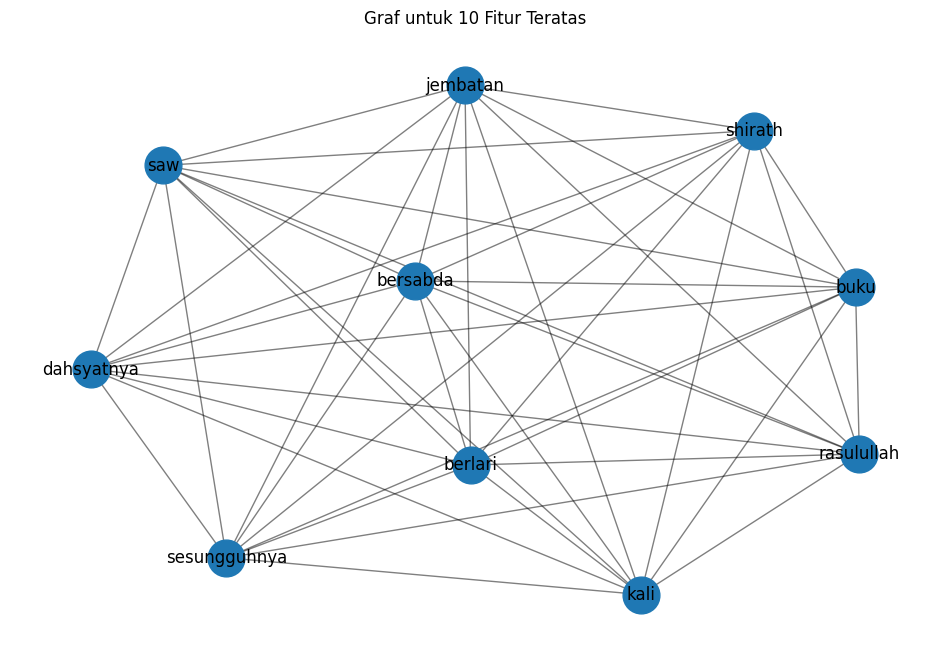

In [9]:
import matplotlib.pyplot as plt
import networkx as nx

# Membuat graf baru hanya untuk fitur teratas
G_top_10 = nx.Graph()

# Menambahkan node teratas ke graf
for feature in top_10_features:
    G_top_10.add_node(feature)

# Pastikan df_tfidf_1berita adalah nama yang benar dari dataframe yang mengandung data biner (TF-IDF)
if 'df_tfidf_1berita' in locals():
    # Menambahkan edge berdasarkan co-occurrence dari fitur teratas
    for i in range(len(df_tfidf_1berita)):
        features = df_tfidf_1berita.iloc[i]
        active_features = features[features == 1].index.tolist()
        active_top_10_features = [f for f in active_features if f in top_10_features]

        for j in range(len(active_top_10_features)):
            for k in range(j + 1, len(active_top_10_features)):
                G_top_10.add_edge(active_top_10_features[j], active_top_10_features[k])

    # Mengatur ukuran figure untuk visualisasi graf
    plt.figure(figsize=(12, 8))

    # Menggambar graf fitur teratas
    pos = nx.spring_layout(G_top_10)
    nx.draw_networkx_nodes(G_top_10, pos, node_size=700)
    nx.draw_networkx_edges(G_top_10, pos, width=1.0, alpha=0.5)
    nx.draw_networkx_labels(G_top_10, pos, font_size=12, font_family='sans-serif')

    # Menampilkan graf
    plt.title('Graf untuk 10 Fitur Teratas')
    plt.axis('off')  # Menyembunyikan sumbu
    plt.show()
else:
    print("DataFrame 'df_tfidf_1berita' tidak ditemukan. Pastikan proses TF-IDF sudah dilakukan.")


In [10]:
# Menghitung closeness centrality
closeness_centrality = nx.closeness_centrality(G_top_10)

# Menghitung betweenness centrality
betweenness_centrality = nx.betweenness_centrality(G_top_10)

# Konversi hasil centrality ke DataFrame untuk lebih mudah dilihat
df_closeness_centrality = pd.DataFrame(closeness_centrality.items(), columns=['Node', 'Closeness Centrality'])
df_betweenness_centrality = pd.DataFrame(betweenness_centrality.items(), columns=['Node', 'Betweenness Centrality'])

# Menggabungkan semua centrality ke dalam satu DataFrame
df_centrality = pd.merge(df_degree_centrality_sorted, df_closeness_centrality, on='Node')
df_centrality = pd.merge(df_centrality, df_betweenness_centrality, on='Node')

# Menampilkan hasil centrality
print(df_centrality)

           Node  Degree Centrality  Closeness Centrality  \
0       shirath           0.155039                   1.0   
1    rasulullah           0.155039                   1.0   
2    dahsyatnya           0.155039                   1.0   
3      jembatan           0.155039                   1.0   
4           saw           0.155039                   1.0   
5          kali           0.155039                   1.0   
6          buku           0.155039                   1.0   
7      bersabda           0.155039                   1.0   
8  sesungguhnya           0.155039                   1.0   
9       berlari           0.155039                   1.0   

   Betweenness Centrality  
0                     0.0  
1                     0.0  
2                     0.0  
3                     0.0  
4                     0.0  
5                     0.0  
6                     0.0  
7                     0.0  
8                     0.0  
9                     0.0  


In [11]:
# Mengambil kata kunci dengan nilai TF-IDF tertinggi untuk setiap dokumen
kata_kunci = df_tfidf_1berita.idxmax(axis=1)
print("\nKata kunci dari setiap dokumen:")
for i, kata in enumerate(kata_kunci):
    print(f"Dokumen {i+1}: {kata}")


Kata kunci dari setiap dokumen:
Dokumen 1: air
